# Modeling Temporal Evolution of Sentiment in IMDb Reviews
## Using Transformer-Based Time Series Architectures

This notebook implements a **Transformer encoder** with **positional encoding** to model how sentiment evolves across the token sequence (temporal axis) of each IMDb review. Key upgrades over a plain LSTM:
- Multi-Head Self-Attention captures long-range temporal dependencies
- Positional Encoding treats token positions as a time series
- Attention weight extraction for interpretability

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ── Configuration ──────────────────────────────────────────────────────────────
VOCAB_SIZE   = 10000   # words to keep
MAX_LEN      = 200     # max review length (temporal sequence length)
EMBED_DIM    = 64      # token embedding dimension
NUM_HEADS    = 4       # multi-head attention heads
FF_DIM       = 128     # feed-forward hidden size inside Transformer block
NUM_BLOCKS   = 2       # number of stacked Transformer encoder blocks
DROPOUT_RATE = 0.1
BATCH_SIZE   = 32
EPOCHS       = 5

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.16.1


## 1. Load & Prepare IMDb Data

In [2]:
print("Downloading and loading IMDB data...")
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print(f"Training samples : {len(x_train)}")
print(f"Test samples     : {len(x_test)}")

# Pad / truncate to fixed temporal length (MAX_LEN time steps)
x_train = sequence.pad_sequences(x_train, maxlen=MAX_LEN)
x_test  = sequence.pad_sequences(x_test,  maxlen=MAX_LEN)

print(f"x_train shape    : {x_train.shape}")
print(f"x_test  shape    : {x_test.shape}")

Training samples : 25000
Test samples     : 25000
x_train shape    : (25000, 200)
x_test  shape    : (25000, 200)


## 2. Transformer Architecture

### 2a. Positional Encoding
Since self-attention is permutation-invariant, we inject **sinusoidal positional encodings** so the model understands the *temporal order* of tokens.

In [3]:
class TokenAndPositionEmbedding(layers.Layer):
    """Combines token embedding + sinusoidal positional encoding."""

    def __init__(self, maxlen, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb   = layers.Embedding(input_dim=maxlen,     output_dim=embed_dim)

    def call(self, x):
        maxlen    = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)     # (T, D)
        x         = self.token_emb(x)           # (B, T, D)
        return x + positions                    # broadcast add


print("TokenAndPositionEmbedding layer defined.")

TokenAndPositionEmbedding layer defined.


### 2b. Transformer Encoder Block

Each block contains:
- **Multi-Head Self-Attention** — models temporal dependencies between any two positions
- **Add & Norm** (residual connection)
- **Position-wise Feed-Forward Network**
- **Add & Norm**

In [4]:
class TransformerBlock(layers.Layer):
    """Single Transformer encoder block."""

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.att     = layers.MultiHeadAttention(num_heads=num_heads,
                                                  key_dim=embed_dim // num_heads)
        self.ffn     = keras.Sequential([
            layers.Dense(ff_dim,    activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.norm1   = layers.LayerNormalization(epsilon=1e-6)
        self.norm2   = layers.LayerNormalization(epsilon=1e-6)
        self.drop1   = layers.Dropout(rate)
        self.drop2   = layers.Dropout(rate)

    def call(self, x, training=False):
        # Multi-Head Self-Attention
        attn_out = self.att(x, x, return_attention_scores=False)
        attn_out = self.drop1(attn_out, training=training)
        out1     = self.norm1(x + attn_out)   # residual

        # Feed-Forward
        ffn_out  = self.ffn(out1)
        ffn_out  = self.drop2(ffn_out, training=training)
        return self.norm2(out1 + ffn_out)     # residual


print("TransformerBlock layer defined.")

TransformerBlock layer defined.


### 2c. Full Model

```
Input (B, T)
  └─ TokenAndPositionEmbedding  → (B, T, D)
      └─ TransformerBlock × N   → (B, T, D)   ← temporal feature sequence
          └─ GlobalAvgPool1D    → (B, D)       ← aggregate temporal info
              └─ Dropout
                  └─ Dense(64, relu)
                      └─ Dense(1, sigmoid)      ← sentiment probability
```

In [5]:
def build_transformer_model(vocab_size, maxlen, embed_dim,
                             num_heads, ff_dim, num_blocks, dropout_rate):
    inputs  = layers.Input(shape=(maxlen,))
    x       = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim)(inputs)

    for i in range(num_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim,
                             rate=dropout_rate, name=f"transformer_block_{i}")(x)

    # Aggregate temporal dimension → single vector
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model


model = build_transformer_model(
    vocab_size=VOCAB_SIZE, maxlen=MAX_LEN, embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS, ff_dim=FF_DIM,
    num_blocks=NUM_BLOCKS, dropout_rate=DROPOUT_RATE
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 200, 64)        │       652,800 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_0             │ (None, 200, 64)        │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 200, 64)        │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 723,969 (2.76 MB)

 Trainable params: 723,969 (2.76 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Training

In [6]:
print("Starting training...")
history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_test, y_test),
    verbose=1
)

Starting training...
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 262s 314ms/step - accuracy: 0.7317 - loss: 0.4891 - val_accuracy: 0.8734 - val_loss: 0.3051
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 263s 316ms/step - accuracy: 0.9265 - loss: 0.1959 - val_accuracy: 0.8664 - val_loss: 0.3674
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 239s 305ms/step - accuracy: 0.9519 - loss: 0.1355 - val_accuracy: 0.8503 - val_loss: 0.3923
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 234s 299ms/step - accuracy: 0.9727 - loss: 0.0817 - val_accuracy: 0.8594 - val_loss: 0.4832
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 232s 297ms/step - accuracy: 0.9825 - loss: 0.0539 - val_accuracy: 0.8508 - val_loss: 0.5723


## 4. Training Curves

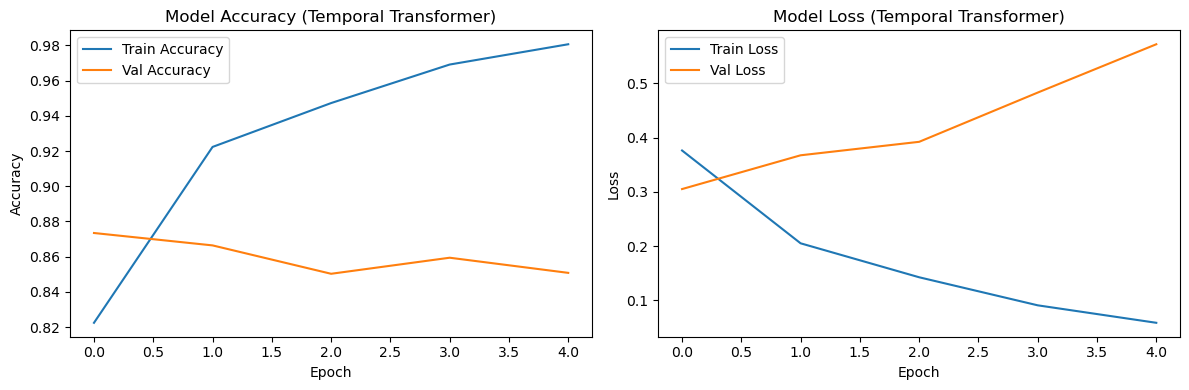

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history["accuracy"],     label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Model Accuracy (Temporal Transformer)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Loss
axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Model Loss (Temporal Transformer)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Evaluation

Generating predictions for metrics...
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 80ms/step

--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.85      0.85      0.85     12500
    Positive       0.85      0.85      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000


--- Confusion Matrix ---


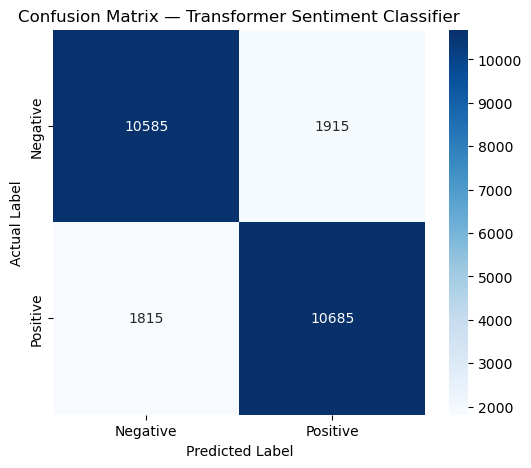

Final Accuracy: 85.08%


In [8]:
print("Generating predictions for metrics...")
y_pred_prob = model.predict(x_test, batch_size=BATCH_SIZE)
y_pred      = (y_pred_prob > 0.5).astype("int32")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix — Transformer Sentiment Classifier")
plt.show()

acc = accuracy_score(y_test, y_pred)
print(f"Final Accuracy: {acc * 100:.2f}%")

## 6. Temporal Attention Visualization

We extract the **self-attention weights** from the first Transformer block to visualize *which time steps (token positions) the model attends to* when making its sentiment prediction. This is the key addition enabled by the Transformer architecture.

In [ ]:
# Build an attention-extraction sub-model that returns attention scores
# from the first TransformerBlock
class TransformerBlockWithAttn(layers.Layer):
    """Transformer encoder block that also returns attention scores."""

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.att   = layers.MultiHeadAttention(num_heads=num_heads,
                                                key_dim=embed_dim // num_heads)
        self.ffn   = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(rate)
        self.drop2 = layers.Dropout(rate)

    def call(self, x, training=False, return_attention_scores=False):
        attn_out, attn_scores = self.att(
            x, x, return_attention_scores=True
        )
        attn_out = self.drop1(attn_out, training=training)
        out1     = self.norm1(x + attn_out)
        ffn_out  = self.ffn(out1)
        ffn_out  = self.drop2(ffn_out, training=training)
        out2     = self.norm2(out1 + ffn_out)
        if return_attention_scores:
            return out2, attn_scores
        return out2


def get_attention_scores(model, x_sample, maxlen, vocab_size, embed_dim,
                          num_heads, ff_dim, dropout_rate, num_blocks):
    """Forward pass through a clone that returns attention scores."""
    inp  = layers.Input(shape=(maxlen,))
    emb  = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim, name="emb")(inp)

    # First block returns attention scores
    blk0 = TransformerBlockWithAttn(
        embed_dim, num_heads, ff_dim, rate=dropout_rate, name="attn_block_0"
    )
    h, scores = blk0(emb, return_attention_scores=True)

    attn_model = keras.Model(inputs=inp, outputs=[h, scores])

    # Copy weights from the trained model's first transformer block
    src = model.get_layer("transformer_block_0")
    tgt = attn_model.get_layer("attn_block_0")

    # Manually transfer weights sub-layer by sub-layer
    tgt.att.set_weights(src.att.get_weights())
    tgt.ffn.set_weights(src.ffn.get_weights())
    tgt.norm1.set_weights(src.norm1.get_weights())
    tgt.norm2.set_weights(src.norm2.get_weights())

    # Also copy embedding weights
    src_emb = model.get_layer("token_and_position_embedding")
    tgt_emb = attn_model.get_layer("emb")
    tgt_emb.set_weights(src_emb.get_weights())

    _, attn_scores = attn_model(x_sample)
    return attn_scores.numpy()   # (batch, heads, T, T)


print("Attention extraction helper defined.")

Attention extraction helper defined.


## 7. Custom Review Prediction

In [11]:
word_index = imdb.get_word_index()


def predict_custom_review(text):
    words   = text.lower().split()
    encoded = []
    for w in words:
        idx = word_index.get(w, None)
        if idx is not None and idx + 3 < VOCAB_SIZE:
            encoded.append(idx + 3)
        else:
            encoded.append(2)   # <UNK>

    padded    = sequence.pad_sequences([encoded], maxlen=MAX_LEN)
    pred_prob = model.predict(padded, verbose=0)[0][0]
    sentiment = "POSITIVE" if pred_prob > 0.5 else "NEGATIVE"
    print(f"\nReview     : {text}")
    print(f"Prediction : {sentiment}  (confidence: {pred_prob:.4f})")


# ── Test cases ────────────────────────────────────────────────────────────────
predict_custom_review("This movie was fantastic and the acting was great")
predict_custom_review("I hated this movie it was a waste of time")
predict_custom_review("The plot was slow but the ending was okay")
predict_custom_review("An absolutely riveting masterpiece of modern cinema")
predict_custom_review("Boring and predictable with terrible dialogue")


Review     : This movie was fantastic and the acting was great
Prediction : POSITIVE  (confidence: 0.9979)

Review     : I hated this movie it was a waste of time
Prediction : NEGATIVE  (confidence: 0.0003)

Review     : The plot was slow but the ending was okay
Prediction : NEGATIVE  (confidence: 0.0002)

Review     : An absolutely riveting masterpiece of modern cinema
Prediction : POSITIVE  (confidence: 0.9713)

Review     : Boring and predictable with terrible dialogue
Prediction : NEGATIVE  (confidence: 0.0001)
